In [12]:
import matplotlib.pyplot as plt
import torch 
import pandas as pd

from model_zoo.configs import *
from model_zoo.vit_homemade import ViT, ViT_merger
from model_zoo.covit import CoViT

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

vit_homemade_conf_dict = {}
vit_merger_homemade_conf_dict = {}

covit_conf_dict = {}
covit_merger_conf_dict = {}

vit_homemade_dict = {}
vit_merger_homemade_dict = {}

covit_dict = {}
covit_merger_dict = {}

#vit_homemade_conf_dict['vit_D1_E512_H1_R224_P16'] = vit_D1_E512_H1_R224_P16
#vit_homemade_conf_dict['vit_D1_E512_H4_R224_P16'] = vit_D1_E512_H4_R224_P16
#vit_homemade_conf_dict['vit_D4_E512_H1_R224_P16'] = vit_D4_E512_H1_R224_P16
#vit_homemade_conf_dict['vit_D4_E512_H4_R224_P16'] = vit_D4_E512_H4_R224_P16
#vit_homemade_conf_dict['vit_D8_E512_H1_R224_P16'] = vit_D8_E512_H1_R224_P16
#vit_homemade_conf_dict['vit_D8_E512_H4_R224_P16'] = vit_D8_E512_H4_R224_P16
#vit_homemade_conf_dict['vit_D8_E512_H4_R224_P32'] = vit_D8_E512_H4_R224_P32
#vit_homemade_conf_dict['vit_D12_E512_H8_R224_P32'] = vit_D12_E512_H8_R224_P32

#vit_homemade_conf_dict['vit_D4_E128_H1_R224_P32'] = vit_D4_E128_H1_R224_P32
vit_homemade_conf_dict['vit_D4_E128_H4_R224_P32'] = vit_D4_E128_H4_R224_P32
#vit_homemade_conf_dict['vit_D8_E128_H1_R224_P32'] = vit_D8_E128_H1_R224_P32
#vit_homemade_conf_dict['vit_D8_E128_H4_R224_P32'] = vit_D8_E128_H4_R224_P32


#vit_merger_homemade_conf_dict['vit_merger_D4_E128_H1_R224_P32'] = vit_merger_D4_E128_H1_R224_P32
#vit_merger_homemade_conf_dict['vit_merger_D4_E128_H4_R224_P32'] = vit_merger_D4_E128_H4_R224_P32
#vit_merger_homemade_conf_dict['vit_merger_D8_E128_H1_R224_P32'] = vit_merger_D8_E128_H1_R224_P32
#vit_merger_homemade_conf_dict['vit_merger_D8_E128_H4_R224_P32'] = vit_merger_D8_E128_H4_R224_P32



#covit_conf_dict['covit_D4_E128_K3_R224_P32'] = covit_D4_E128_K3_R224_P32
covit_conf_dict['covit_D4_E128_K3333_R224_P32'] = covit_D4_E128_K3333_R224_P32
#covit_conf_dict['covit_D8_E128_K3_R224_P32'] = covit_D8_E128_K3_R224_P32
#covit_conf_dict['covit_D8_E128_K3333_R224_P32'] = covit_D8_E128_K3333_R224_P32



for net_name, conf in vit_homemade_conf_dict.items():
    vit_homemade_dict[net_name] = ViT(
                                    in_channels=conf['embedding']['in_channels'],
                                    patch_size=conf['embedding']['patch_size'],
                                    em_size=conf['embedding']['em_size'],
                                    img_size=conf['embedding']['img_size'],
                                    depth=conf['encoder']['depth'],
                                    n_classes=conf['cls_head']['n_classes'],
                                    forward_expansion = conf['encoder']['MLP_expansion'],
                                    forward_drop_out = conf['encoder']['MLP_drop_out'],
                                    d_K = conf['encoder']['d_K'],
                                    d_V = conf['encoder']['d_V'],
                                    num_heads = conf['encoder']['num_heads'],
                                    drop_out = conf['encoder']['att_drop_out']
                                    ) 

for net_name, conf in vit_merger_homemade_conf_dict.items():
    vit_merger_homemade_dict[net_name] = ViT_merger(
                                    in_channels=conf['embedding']['in_channels'],
                                    patch_size=conf['embedding']['patch_size'],
                                    em_size=conf['embedding']['em_size'],
                                    img_size=conf['embedding']['img_size'],
                                    depth=conf['encoder']['depth'],
                                    n_classes=conf['cls_head']['n_classes'],
                                    forward_expansion = conf['encoder']['MLP_expansion'],
                                    forward_drop_out = conf['encoder']['MLP_drop_out'],
                                    d_K = conf['encoder']['d_K'],
                                    d_V = conf['encoder']['d_V'],
                                    num_heads = conf['encoder']['num_heads'],
                                    drop_out = conf['encoder']['att_drop_out']
                                    ) 


for net_name, conf in covit_conf_dict.items():
    covit_dict[net_name] = CoViT(
                                    in_channels=conf['embedding']['in_channels'],
                                    patch_size=conf['embedding']['patch_size'],
                                    em_size=conf['embedding']['em_size'],
                                    img_size=conf['embedding']['img_size'],
                                    depth=conf['encoder']['depth'],
                                    n_classes=conf['cls_head']['n_classes'],
                                    forward_expansion = conf['encoder']['MLP_expansion'],
                                    forward_drop_out = conf['encoder']['MLP_drop_out'],
                                    kernel_size_group = conf['encoder']['kernel_size_group'],
                                    stride_group = conf['encoder']['stride_group'],
                                    padding_group = conf['encoder']['padding_group'],
                                    ) 
net_dict = {}
net_dict.update(vit_homemade_dict)
net_dict.update(vit_merger_homemade_dict)
net_dict.update(covit_dict)

In [13]:
layer_tot = 4
df_elder = pd.DataFrame()
for net_name, net in net_dict.items():
    df_tot = pd.read_csv(f'./log_zoo/singular_val_detail/cifar10/{net_name}_epoch{300}.csv')
    df_old = pd.DataFrame()
    for i in range(1,layer_tot+1):
        df_new = pd.DataFrame(df_tot, columns=[f'layer{i}-top1', f'layer{i}-top2', 
                                               f'layer{i}-top3',f'layer{i}-top4',
                                               f'layer{i}-top5'])
        df_new = df_new.rename(columns={f'layer{i}-top1':'Top1', f'layer{i}-top2':'Top2',
                               f'layer{i}-top3':'Top3', f'layer{i}-top4':'Top4', 
                               f'layer{i}-top5':'Top5'})
        df_new.insert(0, 'Layer', f'layer{i}')  
        df_old = pd.concat([df_old, df_new], ignore_index=True)

    df_old.insert(0, 'Network', net_name)
    df_elder = pd.concat([df_elder, df_old], ignore_index=True)

In [14]:
df_elder

,Network,Layer,Top1,Top2,Top3,Top4,Top5
0,vit_D4_E128_H1_R224_P32,layer1,13.494493,6.863575,6.594258,6.452207,6.338730
1,vit_D4_E128_H1_R224_P32,layer1,6.763444,6.609631,6.187999,6.153268,5.960125
2,vit_D4_E128_H1_R224_P32,layer1,13.546113,11.732636,8.207050,7.384991,6.976073
3,vit_D4_E128_H1_R224_P32,layer1,6.651340,6.039588,6.011899,5.948850,5.895142
4,vit_D4_E128_H1_R224_P32,layer1,6.319091,5.982331,5.522284,5.489389,5.439106
...,...,...,...,...,...,...,...
2195,vit_merger_D4_E128_H1_R224_P32,layer4,6.186308,5.367293,5.094362,5.013043,4.386100
2196,vit_merger_D4_E128_H1_R224_P32,layer4,8.979150,7.537369,6.248048,5.799851,5.046376
2197,vit_merger_D4_E128_H1_R224_P32,layer4,7.630461,7.106054,6.065594,5.134815,4.722504
2198,vit_merger_D4_E128_H1_R224_P32,layer4,6.861063,5.515112,5.004641,4.933380,4.433321


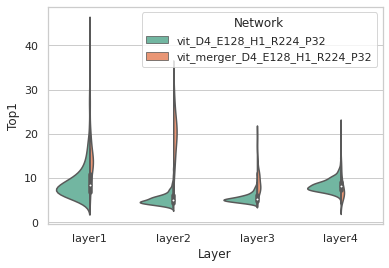

In [17]:
import seaborn as sns
sns.set_theme(style="whitegrid")

ax = sns.violinplot(x="Layer", y="Top1", hue="Network",
                    data=df_elder, palette="Set2", split=True,
                    scale="count")
                    


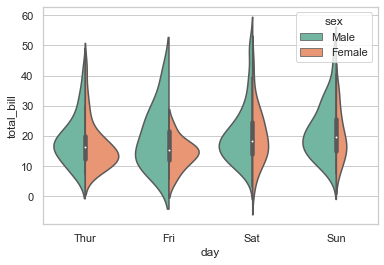

In [2]:
import seaborn as sns
sns.set_theme(style="whitegrid")
tips = sns.load_dataset("tips")
ax = sns.violinplot(x="day", y="total_bill", hue="sex",
                    data=tips, palette="Set2", split=True,
                    scale="count")

In [3]:
tips


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [40]:
df_t = pd.read_csv('./log_zoo/singular_val_ana.csv')

In [41]:
df_t

,Unnamed: 0,data_set,net_name,epoch,max_sigma
0,0,cifar10,vit_D4_E128_H1_R224_P32,300,13.494493
1,0,cifar10,vit_D4_E128_H1_R224_P32,300,9.555897
2,0,cifar10,vit_D4_E128_H1_R224_P32,300,13.546113
3,0,cifar10,vit_D4_E128_H1_R224_P32,300,7.224783
4,0,cifar10,vit_D4_E128_H1_R224_P32,300,7.459183
...,...,...,...,...,...
1108,0,cifar10,covit_D8_E128_K3333_R224_P32,300,6.583457
1109,0,cifar10,covit_D8_E128_K3333_R224_P32,300,6.684649
1110,0,cifar10,covit_D8_E128_K3333_R224_P32,300,6.044131
1111,0,cifar10,covit_D8_E128_K3333_R224_P32,300,6.788180


In [63]:
df_t[df_t['net_name'] == 'vit_D4_E128_H4_R224_P32'].mean()

Unnamed: 0    NaN
data_set      NaN
net_name      NaN
epoch         NaN
max_sigma     NaN
dtype: object

In [23]:
df_elder[df_elder['Network'] == 'vit_merger_D4_E128_H1_R224_P32'].mean()

/tmp/ipykernel_2468681/3904222888.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_elder[df_elder['Network'] == 'vit_merger_D4_E128_H1_R224_P32'].mean()


Top1    12.957409
Top2    10.350015
Top3     9.069204
Top4     8.151875
Top5     7.512390
dtype: float64

In [24]:
df_elder[df_elder['Network'] == 'vit_D4_E128_H1_R224_P32'].mean()

/tmp/ipykernel_2468681/2207928981.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df_elder[df_elder['Network'] == 'vit_D4_E128_H1_R224_P32'].mean()


Top1    7.142989
Top2    6.117130
Top3    5.592363
Top4    5.303921
Top5    5.119409
dtype: float64